# Linear Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data :

In [182]:
X = np.random.rand(100,1)
y = 2 + 3 * X.ravel() + np.random.rand(100)

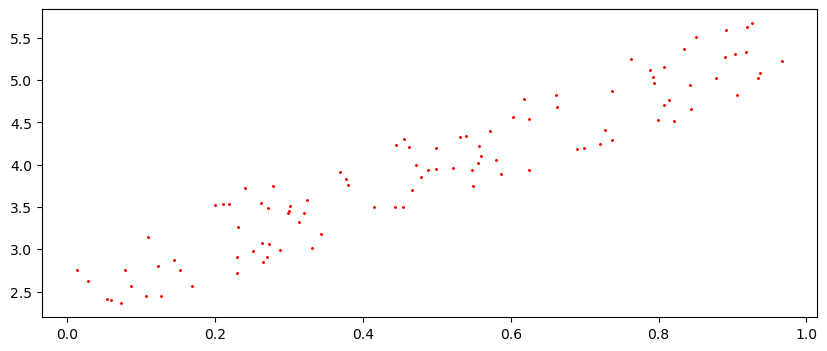

In [183]:
fig = plt.figure(figsize=(10,4))
plt.scatter(X[:, 0], y, color="red", marker=".", s=5)
plt.show()

## Gradient Descent

In [187]:
def Gradient_Descent(X, y, alpha = 0.01, iterations = 1000):
    m,n = X.shape # m,n = 100 ,1
    theta = np.zeros(n) # initialize all parameters with 0
    for _ in range(iterations):
        h = X.dot(theta)
        gradient = (1/m) * X.T.dot(h-y)
        theta -= alpha * gradient
    return theta
X_with_intercept = np.c_[np.ones(X.shape[0]), X]
theta = Gradient_Descent(X_with_intercept, y, alpha=0.01, iterations=1000)

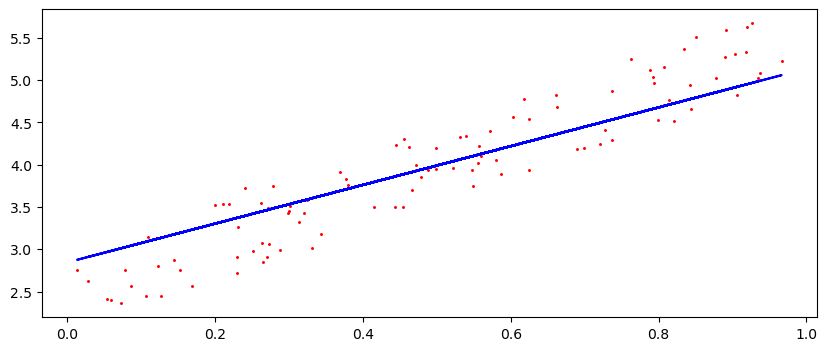

In [188]:
fig = plt.figure(figsize=(10, 4))
plt.scatter(X[:, 0], y, color="red", marker=".", s=5)
y_pred = X_with_intercept.dot(theta)  
plt.plot(X[:, 0], y_pred, color="blue")
plt.show()

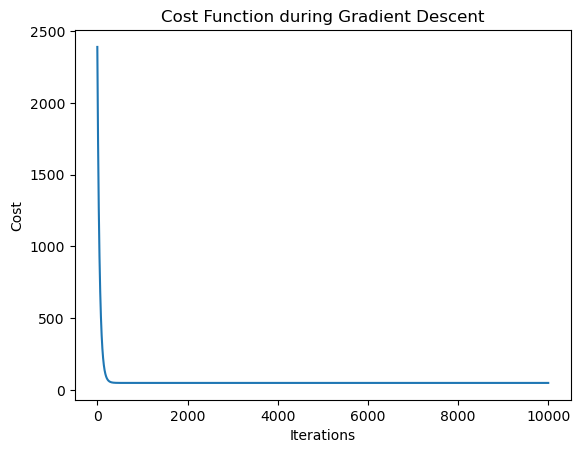

In [169]:
def compute_cost(X, y, theta):
    m = len(y)
    h = X.dot(theta)
    return (1 / (2 * m)) * np.sum((h - y) ** 2)

def Gradient_Descent(X, y, alpha=0.01, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    costs = []  
    
    for _ in range(iterations):
        h = X.dot(theta)
        gradient = (1/m) * X.T.dot(h - y)
        theta -= alpha * gradient
        
        # Compute and store the cost
        cost = compute_cost(X, y, theta)
        costs.append(cost)
    
    return theta, costs
    
X_with_intercept = np.c_[np.ones(X.shape[0]), X]
theta, costs = Gradient_Descent(X_with_intercept, y, alpha=0.01, iterations=10000)

# Plotting the cost function
plt.plot(range(10000), costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function during Gradient Descent")
plt.show()

## Normal Equation

In [115]:
def noraml_eqn(X,y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

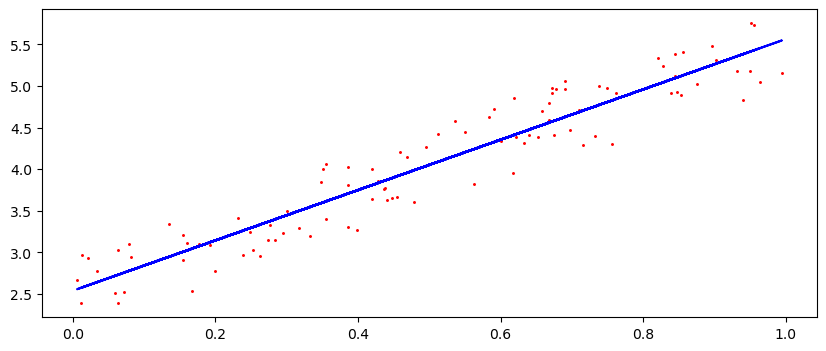

In [128]:
X_with_intercept = np.c_[np.ones(X.shape[0]), X]
theta1 = noraml_eqn(X_with_intercept,y)
fig = plt.figure(figsize=(10, 4))
plt.scatter(X[:, 0], y, color="red", marker=".", s=5)
y_pred = X_with_intercept.dot(theta1)  
plt.plot(X[:, 0], y_pred, color="blue")
plt.show()

## Scikit Learn

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)
y_pred_sklearn = model_sklearn.predict(X_test)

In [147]:
y_pred_sklearn

array([2.75180318, 4.31126939, 3.82591103, 4.61416595, 3.58221221,
       4.67092382, 4.04058218, 5.0845242 , 5.06104872, 4.51474581,
       2.72605455, 4.46075177, 3.94792377, 4.7912833 , 5.00477957,
       2.55453822, 3.60323851, 4.40682754, 4.81202257, 3.84813742])

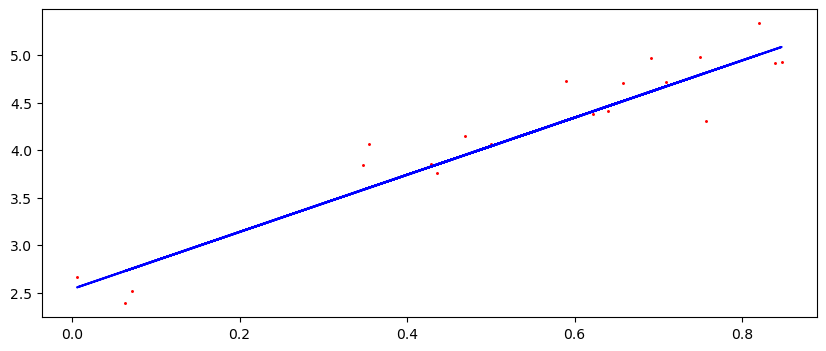

In [148]:
fig = plt.figure(figsize=(10, 4))
plt.scatter(X_test[:, 0], y_test, color="red", marker=".", s=5, label="Actual Data")
plt.plot(X_test[:, 0], y_pred_sklearn, color="blue", label="Predicted Line")
plt.show()

In [228]:
n_samples = 500
n_features = 1

In [229]:
X, y = make_regression(n_samples=n_samples, n_features=n_features,
                       n_informative=5, noise=10, random_state=42)

In [230]:
X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=.2, random_state=1)

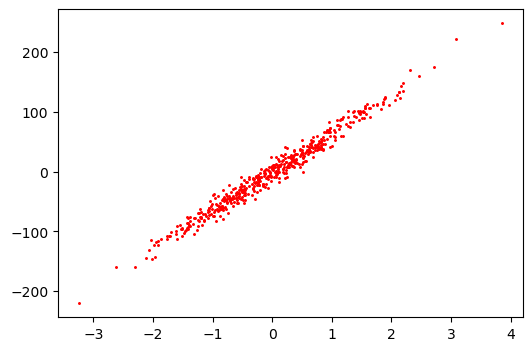

In [235]:
fig = plt.figure(figsize =(6,4))
plt.scatter(X[:,0],y,color = "red", marker = ".", s = 5)
plt.show()

In [248]:
def Gradient_Descent(X, y, alpha = 0.01, iterations = 1000):
    m,n = X.shape # m,n = 100 ,1
    theta = np.zeros(n) # initialize all parameters with 0
    for _ in range(iterations):
        h = X.dot(theta)
        gradient = (1/m) * X.T.dot(h-y)
        theta -= alpha * gradient
    return theta
theta = Gradient_Descent(X_fit, y_fit, alpha = 0.001, iterations = 5000)

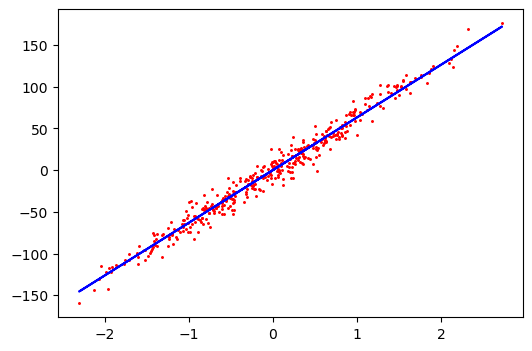

In [249]:
fig = plt.figure(figsize=(6, 4))
plt.scatter(X_fit[:, 0], y_fit, color="red", marker=".", s=5)
y_pred = X_fit.dot(theta)  
plt.plot(X_fit[:, 0], y_pred, color="blue")
plt.show()

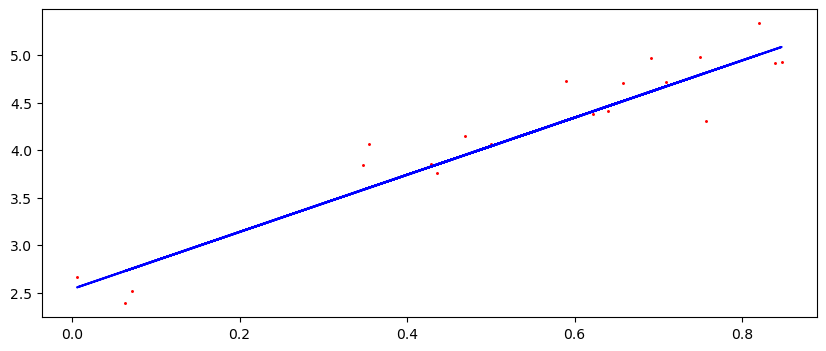

In [245]:
model_sklearn.fit(X_train, y_train)
y_pred_sklearn = model_sklearn.predict(X_test)
fig = plt.figure(figsize=(10, 4))
plt.scatter(X_test[:, 0], y_test, color="red", marker=".", s=5, label="Actual Data")
plt.plot(X_test[:, 0], y_pred_sklearn, color="blue", label="Predicted Line")
plt.show()